# Linear Regression


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn import set_config
set_config(display='text')


## 3. Nonlinear

$$f(x) = \sin(3.2x) + 0.8x$$


### 3. 生成假資料

In [2]:
x = np.linspace(0, 5, 100)
y = np.sin(3.2*x) + 0.8*x + 0.3*np.random.randn(100)

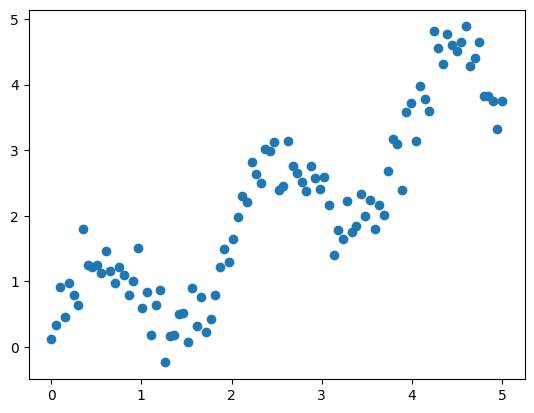

In [3]:
plt.scatter(x,y)

#### nonlinear

In [4]:
regr_lin = LinearRegression()

In [5]:
X = x.reshape(-1, 1)
print(X.shape)

(100, 1)


In [6]:
regr_lin.fit(X,y)

LinearRegression()

0.4919419003586114


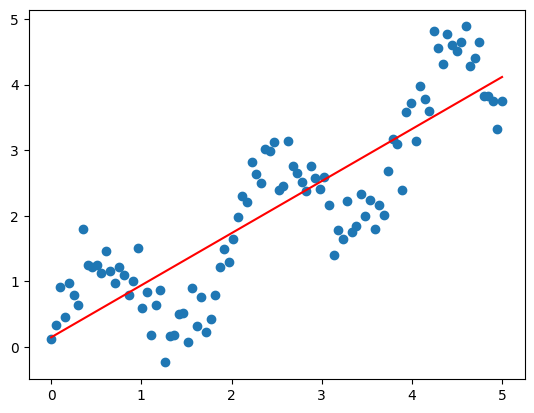

In [7]:
Y=regr_lin.predict(X)
plt.scatter(x,y)
plt.plot(x,Y , color='r')
mse = np.sum((Y-y)**2) / len(y)
print(mse)

果然超級不準, 該如何是好?

#### 多項式

多項式5次方

$$\widehat{y}=xw+b=w_{1}x_{1}+w_{2}x_{1}^{2}+w_{3}x_{1}^{3}+w_{4}x_{1}^{4}+w_{5}x_{1}^{5}+b$$

In [8]:
print(x.shape)

(100,)


In [9]:
X_poly = np.array([[k, k**2, k**3, k**4, k**5] for k in x])  # add k**6 to try it
print(X_poly.shape)

(100, 5)


In [10]:
regr_poly = LinearRegression()

In [11]:
regr_poly.fit(X_poly, y)

LinearRegression()

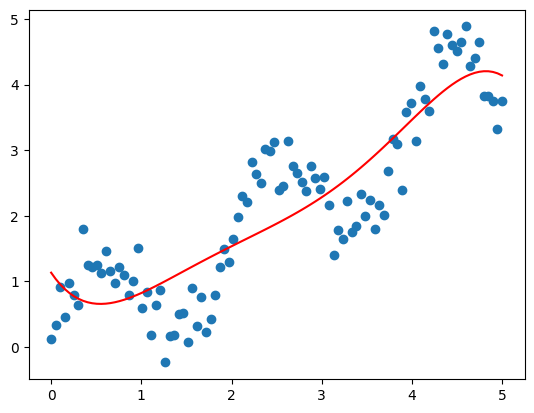

In [12]:
plt.scatter(x,y)
plt.plot(x, regr_poly.predict(X_poly), 'r')

In [13]:
print('Coefficients: ', regr_poly.coef_)
print('interception: ', regr_poly.intercept_)

Coefficients:  [-2.04364531  2.77774705 -1.30683386  0.28498831 -0.02271463]
interception:  1.1322229005844502


In [14]:
W=regr_poly.coef_
b=regr_poly.intercept_
np.dot(X_poly,W.T)+b

array([1.1322229 , 1.03592735, 0.95281814, 0.88195078, 0.82242348,
       0.77337627, 0.73399011, 0.70348597, 0.68112394, 0.66620237,
       0.65805692, 0.65605969, 0.65961836, 0.6681752 , 0.6812063 ,
       0.69822055, 0.71875884, 0.74239311, 0.76872548, 0.79738732,
       0.82803842, 0.86036601, 0.89408395, 0.92893176, 0.96467377,
       1.00109821, 1.03801631, 1.07526142, 1.11268809, 1.1501712 ,
       1.18760505, 1.22490246, 1.26199387, 1.2988265 , 1.33536335,
       1.37158242, 1.40747571, 1.4430484 , 1.47831792, 1.51331307,
       1.5480731 , 1.58264683, 1.61709177, 1.6514732 , 1.68586327,
       1.72034014, 1.75498704, 1.78989141, 1.82514399, 1.8608379 ,
       1.8970678 , 1.93392895, 1.97151632, 2.00992372, 2.04924285,
       2.08956249, 2.13096751, 2.17353804, 2.21734855, 2.26246695,
       2.30895372, 2.35686097, 2.40623158, 2.45709831, 2.50948287,
       2.56339505, 2.61883181, 2.6757764 , 2.73419745, 2.79404809,
       2.85526504, 2.91776771, 2.98145732, 3.04621599, 3.11190

In [15]:
regr_poly.predict(X_poly)

array([1.1322229 , 1.03592735, 0.95281814, 0.88195078, 0.82242348,
       0.77337627, 0.73399011, 0.70348597, 0.68112394, 0.66620237,
       0.65805692, 0.65605969, 0.65961836, 0.6681752 , 0.6812063 ,
       0.69822055, 0.71875884, 0.74239311, 0.76872548, 0.79738732,
       0.82803842, 0.86036601, 0.89408395, 0.92893176, 0.96467377,
       1.00109821, 1.03801631, 1.07526142, 1.11268809, 1.1501712 ,
       1.18760505, 1.22490246, 1.26199387, 1.2988265 , 1.33536335,
       1.37158242, 1.40747571, 1.4430484 , 1.47831792, 1.51331307,
       1.5480731 , 1.58264683, 1.61709177, 1.6514732 , 1.68586327,
       1.72034014, 1.75498704, 1.78989141, 1.82514399, 1.8608379 ,
       1.8970678 , 1.93392895, 1.97151632, 2.00992372, 2.04924285,
       2.08956249, 2.13096751, 2.17353804, 2.21734855, 2.26246695,
       2.30895372, 2.35686097, 2.40623158, 2.45709831, 2.50948287,
       2.56339505, 2.61883181, 2.6757764 , 2.73419745, 2.79404809,
       2.85526504, 2.91776771, 2.98145732, 3.04621599, 3.11190

#### RBF

$$\phi_i = e^{-\| x - c_i \|^2/2\sigma^2}$$

In [16]:
# normal distrubution
def RBF(x, center, sigma):
    k = np.exp(-(x - center)**2/(2*sigma**2))
    return k

In [17]:
sigma = 0.3

In [18]:
X_rbf = np.array([[RBF(k, .5, sigma), 
                  RBF(k, 1.5, sigma),
                  RBF(k, 2.5, sigma),
                  RBF(k, 3.5, sigma),
                  RBF(k, 4.5, sigma)] for k in x])



In [19]:
regr_rbf = LinearRegression()

In [20]:
regr_rbf.fit(X_rbf, y)

LinearRegression()

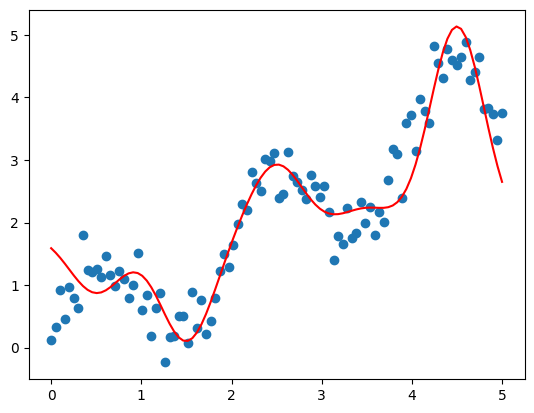

In [21]:
plt.scatter(x,y)
plt.plot(x, regr_rbf.predict(X_rbf), 'r')

In [22]:
print('Coefficients: ', regr_rbf.coef_)
print('interception: ', regr_rbf.intercept_)

Coefficients:  [-0.94644273 -1.72206615  1.10721654  0.39444826  3.30741281]
interception:  1.8258731187466322


#### Comparison

In [23]:
Y_lin = regr_lin.predict(X)
Y_poly = regr_poly.predict(X_poly)
Y_rbf = regr_rbf.predict(X_rbf)

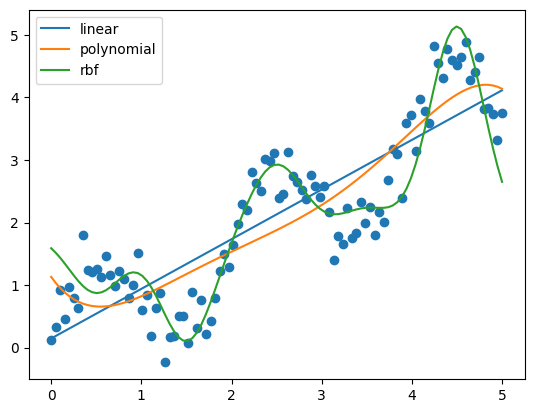

In [24]:
plt.scatter(x,y)

plt.plot(x, Y_lin, label='linear')
plt.plot(x, Y_poly, label='polynomial')
plt.plot(x, Y_rbf, label='rbf')
plt.legend()

## 請計算模型的MSE

In [25]:
print(np.sum((regr_lin.predict(X)-y)**2) / len(y))

0.4919419003586114


In [26]:
print(np.sum((regr_poly.predict(X_poly)-y)**2) / len(y))

0.4235357571617533


In [27]:
print(np.sum((regr_rbf.predict(X_rbf)-y)**2) / len(y))

0.2087524813305888


In [28]:
mse_lin = np.sum((Y_lin - y) ** 2) / len(y)
mse_poly = np.sum((Y_poly - y) ** 2) / len(y)
mse_rbf = np.sum((Y_rbf - y) ** 2) / len(y)

print('Linear MSE:', mse_lin)
print('Polynomial MSE:', mse_poly)
print('RBF MSE:', mse_rbf)


Linear MSE: 0.4919419003586114
Polynomial MSE: 0.4235357571617533
RBF MSE: 0.2087524813305888


In [29]:
mse_result = {
    'linear': mse_lin,
    'polynomial': mse_poly,
    'rbf': mse_rbf,
}
best_model = min(mse_result, key=mse_result.get)
print('Best model:', best_model)


Best model: rbf
